# 03 — Statistical forecasting: baselines and SARIMAX

This notebook evaluates classical forecasting approaches under **rolling-origin
backtesting**: simple baselines first (they are surprisingly hard to beat on
stable demand), then per-clinic SARIMAX with exogenous marketing inputs.

Statistical models matter in healthcare operations because they are
transparent, fast to fit per series, and their failure modes are well
understood — important when forecasts feed staffing decisions.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

pd.set_option("display.max_columns", 80)
plt.rcParams["figure.figsize"] = (11, 4)

In [2]:
from clinic_forecast.data import generate_network_data

data_path = PROJECT_ROOT / "data" / "processed" / "clinic_daily_usage.csv"
if data_path.exists():
    usage = pd.read_csv(data_path, parse_dates=["date"])
else:
    usage = generate_network_data().usage
    usage["date"] = pd.to_datetime(usage["date"])

print(usage.shape)

(17532, 32)


## Rolling-origin validation setup

We never evaluate on a single train/test split: a model can get lucky on one
holdout window. `RollingOriginSplitter` produces forward-chaining folds — the
training window always ends strictly before the test window starts, so there
is no leakage from the future. Each fold forecasts 28 days, the planning
horizon used throughout the project.

In [3]:
from clinic_forecast.validation import RollingOriginSplitter

splitter = RollingOriginSplitter(initial_train_days=365 * 3, horizon_days=28, max_folds=3)
splitter.summary(usage)

,fold_id,train_start,train_end,test_start,test_end,train_days,test_days,train_rows,test_rows
0,1,2022-01-01,2024-12-30,2024-12-31,2025-01-27,1095,28,13140,336
1,2,2022-01-01,2025-01-27,2025-01-28,2025-02-24,1123,28,13476,336
2,3,2022-01-01,2025-02-24,2025-02-25,2025-03-24,1151,28,13812,336


## Baselines across folds

Seasonal naive (repeat last week) and a 28-day moving average, scored on every
fold and pooled. The seasonal naive handles weekly structure including the
Sunday closures; the moving average smears weekdays and weekends together.

In [4]:
from clinic_forecast.metrics import compute_metrics
from clinic_forecast.models.baseline import moving_average_forecast, seasonal_naive_forecast

baseline_rows = []
scored_folds = []
for train, test, fold in splitter.split(usage):
    for name, forecaster in [
        ("seasonal_naive", lambda tr, te: seasonal_naive_forecast(train=tr, future=te)),
        ("moving_average_28", lambda tr, te: moving_average_forecast(train=tr, future=te, window=28)),
    ]:
        forecast = forecaster(train, test)
        scored = test.merge(forecast, on=["clinic_id", "date"], how="left")
        metrics = compute_metrics(scored["visits"], scored["forecast"])
        baseline_rows.append({"model": name, "fold": fold.fold_id, **metrics.__dict__})
        if name == "seasonal_naive":
            scored_folds.append(scored)

baseline_results = pd.DataFrame(baseline_rows)
baseline_results.groupby("model")[["mae", "rmse", "wape", "bias"]].mean().round(2)

,mae,rmse,wape,bias
model,,,,
moving_average_28,31.57,42.24,28.89,-3.42
seasonal_naive,19.71,32.19,18.44,-10.74


In [5]:
baseline_results.round(2)

,model,fold,mae,rmse,mape,smape,wape,bias
0,seasonal_naive,1,43.60,71.84,45.35,67.09,41.38,-38.39
1,moving_average_28,1,37.83,47.46,31.60,60.48,35.91,-6.99
2,seasonal_naive,2,6.81,10.98,10.18,9.35,5.95,0.27
3,moving_average_28,2,31.59,40.54,25.13,46.02,27.63,-7.85
4,seasonal_naive,3,8.72,13.76,13.52,10.22,7.98,5.90
5,moving_average_28,3,25.30,38.73,21.94,38.56,23.14,4.57


## SARIMAX with exogenous regressors

One SARIMAX model per clinic with weekly seasonal terms and marketing
exogenous inputs. To keep the notebook responsive we fit three clinics on the
final fold; the per-clinic fitting cost is the key *limitation* of the
classical approach for large networks — it scales linearly with the number of
clinics, which motivates the global ML model in notebook 04.

In [6]:
from clinic_forecast.models.sarimax import sarimax_panel_forecast

selected_clinics = ["CLINIC_001", "CLINIC_002", "CLINIC_003"]
*_, (train, test, last_fold) = splitter.split(usage)
train_small = train[train["clinic_id"].isin(selected_clinics)]
test_small = test[test["clinic_id"].isin(selected_clinics)]

sarimax_fcst = sarimax_panel_forecast(
    train=train_small,
    future=test_small,
    exog_cols=["marketing_spend", "campaign_active"],
)
scored_sarimax = test_small.merge(sarimax_fcst, on=["clinic_id", "date"], how="left")
compute_metrics(scored_sarimax["visits"], scored_sarimax["forecast"])

ForecastMetrics(mae=7.6523626524455555, rmse=10.064234281828737, mape=16.48214644867514, smape=29.13754325422808, wape=6.592128630965302, bias=2.0994777233010233)

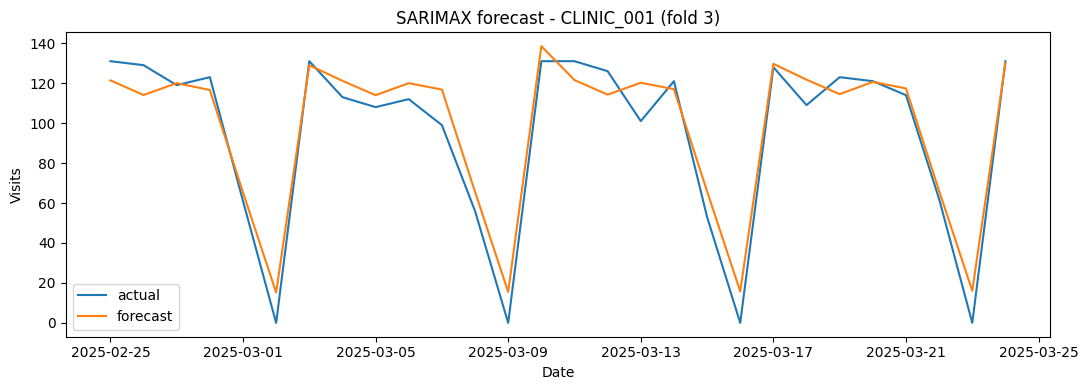

In [7]:
from clinic_forecast.visualization import plot_actual_vs_forecast

one = scored_sarimax[scored_sarimax["clinic_id"] == selected_clinics[0]]
plot_actual_vs_forecast(one, title=f"SARIMAX forecast - {selected_clinics[0]} (fold {last_fold.fold_id})")

## Optional: Prophet

Prophet is an optional dependency (`poetry install --with optional`). It is
useful when analysts need decomposable trend/seasonality/holiday components
with little tuning, at the cost of another per-series fitting loop.

In [8]:
try:
    from clinic_forecast.models.optional_prophet import prophet_forecast_one_clinic

    clinic_id = "CLINIC_001"
    train_one = train[train["clinic_id"] == clinic_id]
    prophet_fcst = prophet_forecast_one_clinic(train_one, periods=28)
    print(prophet_fcst.head())
except ImportError as exc:
    print(exc)
    print("Skipping Prophet example. Install optional dependencies to enable this cell.")

Prophet is not installed. Run `poetry install --with optional` to enable it.
Skipping Prophet example. Install optional dependencies to enable this cell.


## Insights

- Rolling-origin folds give a far more honest picture than a single split;
  baseline WAPE varies meaningfully between folds.
- The seasonal naive baseline is strong on this data because weekly structure
  dominates — any candidate model must beat it to earn its complexity.
- SARIMAX captures weekly seasonality and uses marketing as an exogenous
  signal, but per-clinic fitting limits scalability across large networks.

**Next:** notebook 04 trains one global ML model for all clinics and evaluates
it on the same folds.